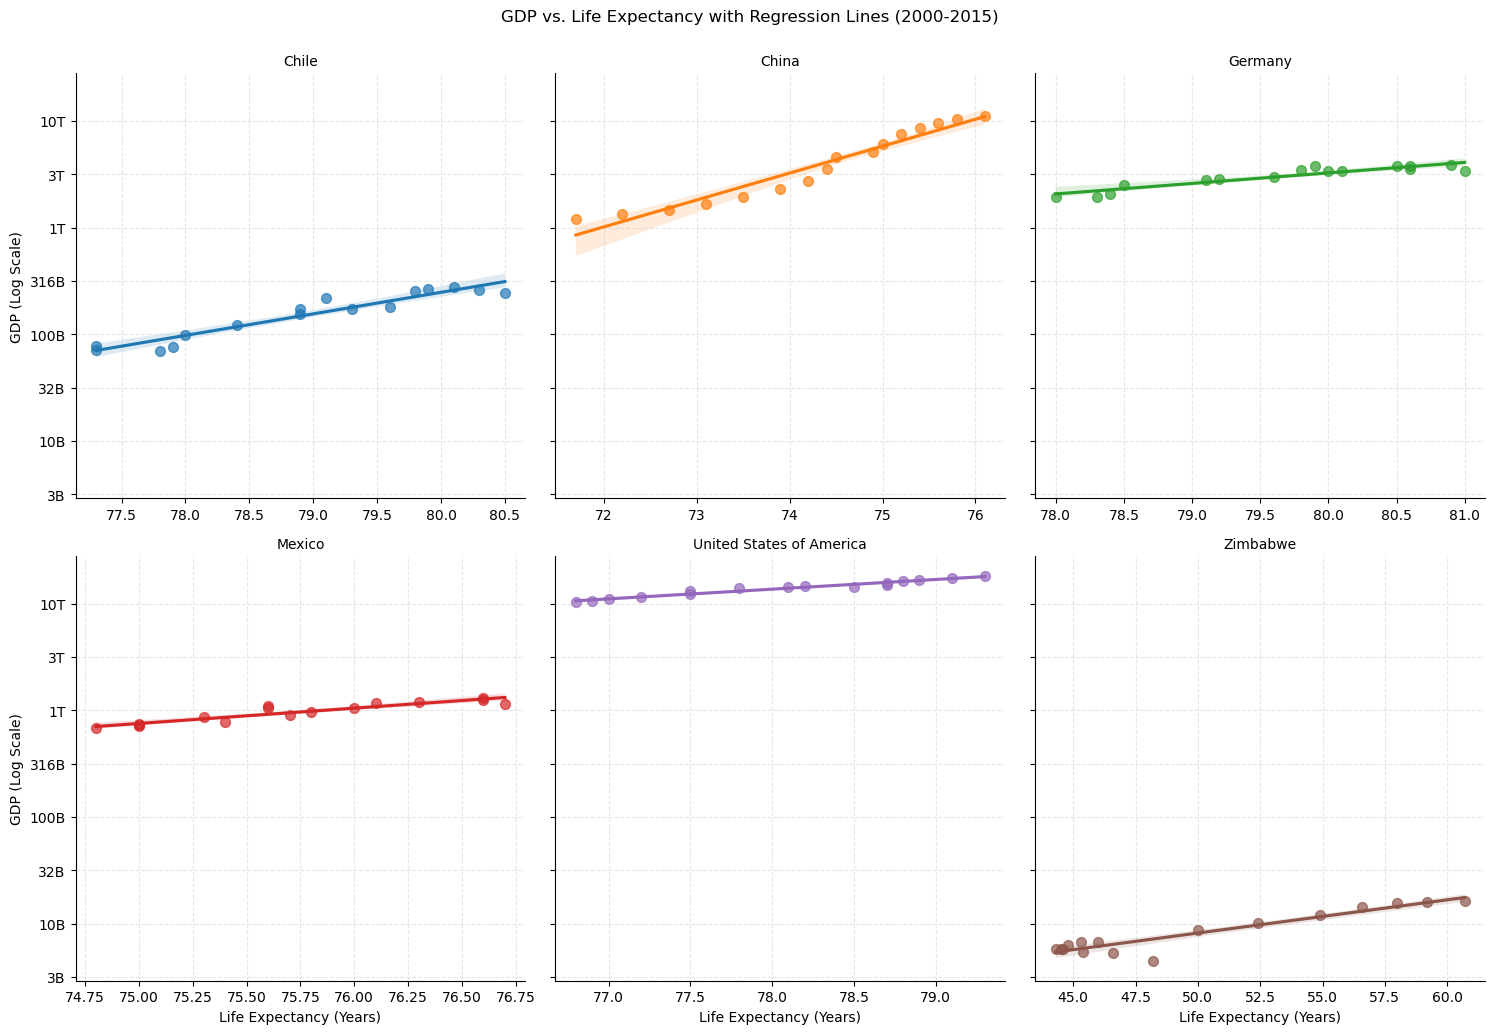

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# --- 1. Load Data ---
df = pd.read_csv('all_data.csv')

df.rename(columns={'Life expectancy at birth (years)': 'life_expectancy'}, inplace=True)
# --- 2. Create Log-Transformed Column ---
# To plot a linear regression on a log scale, we must
# calculate the regression on the log-transformed data.
df['log_GDP'] = np.log10(df['GDP'])

df['log_GDP'] = np.log10(df['GDP'])

# --- 3. Define the Log GDP Formatter ---
def format_log_gdp(value, pos):
    gdp = 10**value  # Convert log value back to a real number
    if gdp >= 1e12:
        return f'{gdp/1e12:.0f}T'  # Trillions
    if gdp >= 1e9:
        return f'{gdp/1e9:.0f}B'   # Billions
    if gdp >= 1e6:
        return f'{gdp/1e6:.0f}M'   # Millions
    return f'{gdp:.0f}'

log_gdp_formatter = ticker.FuncFormatter(format_log_gdp)

# --- 4. Create the Plot (with fix) ---
g = sns.lmplot(
    data=df,
    x='life_expectancy',
    y='log_GDP',
    col='Country',
    hue='Country',
    col_wrap=3,
    # --- This is the corrected part ---
    facet_kws={
        'sharex': False,
        'sharey': True
    },
    # ----------------------------------
    scatter_kws={'s': 50, 'alpha': 0.7}
)

# --- 5. Format the Plot ---
g.fig.suptitle('GDP vs. Life Expectancy with Regression Lines (2000-2015)', y=1.03)
g.set_axis_labels("Life Expectancy (Years)", "GDP (Log Scale)")
g.set_titles("{col_name}")

# Apply the custom log formatter and grid
for ax in g.axes.flat:
    if ax.collections:
        ax.yaxis.set_major_formatter(log_gdp_formatter)
        ax.yaxis.set_minor_formatter(ticker.NullFormatter())
        ax.grid(True, which="both", ls="--", alpha=0.3)

plt.show()